## Import Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
## Importing the data from a csv file
salary_df = pd.read_csv('salary.csv')

In [3]:
## Glimpsing the first few rows
salary_df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


## Exploratory Data Analysis

In [4]:
# Column info
salary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Salary           35 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 688.0 bytes


In [5]:
# Descriptive Statistics
salary_df.describe()

,YearsExperience,Salary
count,35.000000,35.000000
mean,6.308571,83945.600000
std,3.618610,32162.673003
min,1.100000,37731.000000
25%,3.450000,57019.000000
50%,5.300000,81363.000000
75%,9.250000,113223.500000
max,13.500000,139465.000000


In [6]:
## Missing data by column
salary_df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

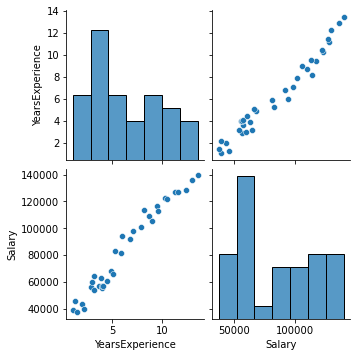

In [7]:
# Pairplot to visualize relationships
sns.pairplot(salary_df)

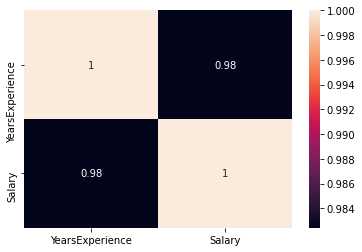

In [8]:
# Visualize correlation with a heatmap
corr_matrix = salary_df.corr()
sns.heatmap(corr_matrix, annot = True)
plt.show()

## Model Preparation

#### Designating Target and Features

In [9]:
X = salary_df[['YearsExperience']]
y = salary_df[['Salary']]

In [10]:
# Ensure both variables are floats
X = np.array(X).astype('float32')
y = np.array(y).astype('float32')

#### Splitting into train and test sets

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

## Training the model with sklearn

In [12]:
# fitting the model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score

regresssion_model_sklearn = LinearRegression(fit_intercept = True)
regresssion_model_sklearn.fit(X_train, y_train)

LinearRegression()

## Evaluating the model built with sklearn

In [13]:
## Variance Explained (R-squared)
regresssion_model_r2 = regresssion_model_sklearn.score(X_test, y_test)
regresssion_model_r2

0.9713365710736381

In [14]:
## Coefficient and intercept of the model
print('Linear Model Coefficient (m): ', regresssion_model_sklearn.coef_)
print('Linear Model Coefficient (b): ', regresssion_model_sklearn.intercept_)

Linear Model Coefficient (m):  [[8711.612]]
Linear Model Coefficient (b):  [29556.312]


#### Visualizing the model

In [15]:
y_predict = regresssion_model_sklearn.predict(X_test)

Text(0.5, 1.0, 'Salary vs. Years of Experience')

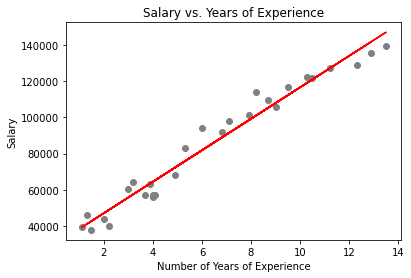

In [16]:
plt.scatter(X_train, y_train, color = 'gray')
plt.plot(X_train, regresssion_model_sklearn.predict(X_train), color = 'red')
plt.ylabel('Salary')
plt.xlabel('Number of Years of Experience')
plt.title('Salary vs. Years of Experience')

----

# Training a linear model using Sagemaker's Linear Learner

## Importing Libraries | Creating A Session | Retrieving the execution role

In [17]:
# Boto3 is the AWS SDK for Python
# Boto3 allows a Python developer to write software that makes use of services like Amazon S3 and Amazon EC2

import sagemaker
import boto3
import io
import sagemaker.amazon.common as smac
import os
import tensorflow as tf

# Create a sagemaker session
sagemaker_session = sagemaker.Session()

# Define a S3 bucket and prefix that we want to use in this session
# Bucket needs to be created beforehand
# Note that the prefix is the subfolder within the bucket
bucket = "sagemaker-practical-example"
prefix = 'linear_model'

# Retrieve the execution role for the notebook instance
# Note that this is the IAM role you created when you freated your notebook instance 
role = sagemaker.get_execution_role()

## Training Data: Convert Data into RecordIO format

In [18]:
# Converts target variable to a vector
y_train = y_train[:,0]

In [19]:
# Creates an in-memory byte array
buf = io.BytesIO()

# formats data to the RecordIO format
smac.write_numpy_to_dense_tensor(buf, X_train, y_train)
buf.seek(0)

0

## Training Data: Upload Data to S3

In [20]:
# Name of the file
key = 'linear-train-data'

# Uploads the data in record-io format to the designated S3 bucket. Will be accessed later for training
boto3.resource('s3').Bucket(bucket).Object(os.path.join(prefix,'train',key)).upload_fileobj(buf)

/home/ec2-user/anaconda3/envs/amazonei_tensorflow2_p36/lib/python3.6/site-packages/boto3/compat.py:88: PythonDeprecationWarning: Boto3 will no longer support Python 3.6 starting May 30, 2022. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.7 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


#### Print Out file path 

In [21]:
s3_train_data = 's3://{}/{}/train/{}'.format(bucket,prefix,key)
print("Training data was uploaded in: {}".format(s3_train_data))

Training data was uploaded in: s3://sagemaker-practical-example/linear_model/train/linear-train-data


## Test Data: Convert Data into RecordIO format

In [22]:
# Converts target variable to a vector
y_test = y_test[:,0]

In [23]:
# Creates an in-memory byte array
buf = io.BytesIO()

# formats data to the RecordIO format
smac.write_numpy_to_dense_tensor(buf, X_test, y_test)
buf.seek(0)

0

## Test Data: Upload Data to S3

In [24]:
# Name of the file
key = 'linear-test-data'

# Uploads the data in record-io format to the designated S3 bucket. Will be accessed later for training
boto3.resource('s3').Bucket(bucket).Object(os.path.join(prefix,'test',key)).upload_fileobj(buf)

#### Print Out file path 

In [25]:
s3_test_data = 's3://{}/{}/test/{}'.format(bucket, prefix, key)
print('Test data was uploaded in: {}'.format(s3_test_data))

Test data was uploaded in: s3://sagemaker-practical-example/linear_model/test/linear-test-data


## Output placeholder to store the output of the model

In [26]:
output_location = 's3://{}/{}/output'.format(bucket,prefix)
print('Training artifacts will be uploaded to: {}'.format(output_location))

Training artifacts will be uploaded to: s3://sagemaker-practical-example/linear_model/output


## Get training container of sagemaker built-in algorithms

In [27]:
from sagemaker.amazon.amazon_estimator import get_image_uri
container = get_image_uri(boto3.Session().region_name, 'linear-learner')

The method get_image_uri has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


#### Create an instance for training and train the model

In [28]:
# Instance to create the linear learner model
linear = sagemaker.estimator.Estimator(
    container,
    role,
    train_instance_count = 1,
    train_instance_type = 'ml.c4.xlarge',
    output_path = output_location,
    sagemaker_session = sagemaker_session
)

# Hyperparamter tuning
linear.set_hyperparameters(
    feature_dim = 1,
    predictor_type = 'regressor',
    mini_batch_size = 5,
    epochs = 5,
    num_models = 32,
    loss = 'absolute_loss'
)

# This method will actually train the model
linear.fit({'train': s3_train_data})

train_instance_count has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
train_instance_type has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


2022-11-04 00:15:41 Starting - Starting the training job...
2022-11-04 00:16:05 Starting - Preparing the instances for trainingProfilerReport-1667520941: InProgress
......
2022-11-04 00:17:09 Downloading - Downloading input data...
2022-11-04 00:17:30 Training - Downloading the training image.........
2022-11-04 00:19:05 Training - Training image download completed. Training in progress.Docker entrypoint called with argument(s): train
Running default environment configuration script
[11/04/2022 00:19:03 INFO 140364144641856] Reading default configuration from /opt/amazon/lib/python3.7/site-packages/algorithm/resources/default-input.json: {'mini_batch_size': '1000', 'epochs': '15', 'feature_dim': 'auto', 'use_bias': 'true', 'binary_classifier_model_selection_criteria': 'accuracy', 'f_beta': '1.0', 'target_recall': '0.8', 'target_precision': '0.8', 'num_models': 'auto', 'num_calibration_samples': '10000000', 'init_method': 'uniform', 'init_scale': '0.07', 'init_sigma': '0.01', 'init_bias

## Deploy the Model by creating an Endpoint

In [42]:
## Deploy the model
linear_regressor = linear.deploy(
    initial_instance_count = 1,
    instance_type = 'ml.m4.xlarge')

---------!

In [44]:
from sagemaker.deserializers import JSONDeserializer
from sagemaker.serializers import CSVSerializer



linear_regressor.CONTENT_TYPE = "text/csv"
linear_regressor.serializer = CSVSerializer()
linear_regressor.deserializer = JSONDeserializer()

### Making Predictions on the Test Data

In [47]:
results = linear_regressor.predict(X_test)

In [48]:
## Quickly look at the results in JSON format
results

{'predictions': [{'score': 45470.5},
  {'score': 102741.9609375},
  {'score': 69631.890625},
  {'score': 42785.8984375},
  {'score': 119744.421875},
  {'score': 62472.9609375},
  {'score': 57103.76171875}]}

In [49]:
## convert the results to an array so we can visualize them later
# Since the result is in json format, we access the scores by iterating through the scores in the predictions
predictions = np.array([r['score'] for r in result['predictions']])
predictions

array([ 45470.5       , 102741.9609375 ,  69631.890625  ,  42785.8984375 ,
       119744.421875  ,  62472.9609375 ,  57103.76171875])

Text(0.5, 1.0, 'Salary vs. Years of Experience')

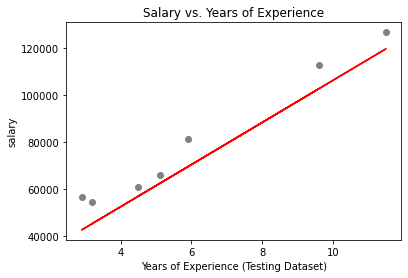

In [50]:
## Visualizing the predictions
# VISUALIZE TEST SET RESULTS
plt.scatter(X_test, y_test, color = 'gray')
plt.plot(X_test, predictions, color = 'red')
plt.xlabel('Years of Experience (Testing Dataset)')
plt.ylabel('salary')
plt.title('Salary vs. Years of Experience')

In [51]:
# Delete the end-point
# Very important! You could incur a cost if you do not delete the endpoint
linear_regressor.delete_endpoint()